In [33]:
# Importing Libraries
import ast
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)



In [34]:
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US_explode = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_explode = df_DA_US.explode('job_skills')
df_DA_US_explode[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
36,NaN,NaN
155,NaN,sql
155,NaN,python
155,NaN,unix
155,NaN,excel


In [35]:
df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)


,count,median
job_skills,,
sql,714,87500.0
excel,472,77500.0
python,408,90000.0
tableau,398,90000.0
power bi,279,87500.0
...,...,...
tidyr,0,NaN
vmware,0,NaN
unity,0,NaN


In [36]:
df_DA_skills = df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_US)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 0.4

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,714,87500.0,5.068863
excel,472,77500.0,3.350845
python,408,90000.0,2.896493
tableau,398,90000.0,2.825500
power bi,279,87500.0,1.980690
r,244,90000.0,1.732216
sas,200,84078.5,1.419849
powerpoint,102,77500.0,0.724123
word,89,75000.0,0.631833


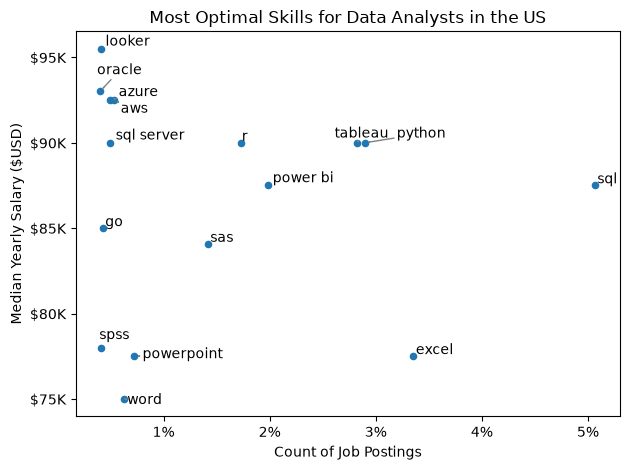

In [37]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter



df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts,
            arrowprops=dict(arrowstyle="->", color='gray', lw=1)
)

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()


In [38]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists
            technology_dict[key] += value
        else:  # if key does not exist
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['power bi',
  'sap',
  'ms access',
  'visio',
  'spss',
  'datarobot',
  'excel',
  'sheets',
  'powerpoint',
  'ssrs',
  'sharepoint',
  'dax',
  'msaccess',
  'ssis',
  'sas',
  'spreadsheet',
  'alteryx',
  'outlook',
  'qlik',
  'word',
  'microstrategy',
  'tableau',
  'esquisse',
  'cognos',
  'powerbi',
  'nuix',
  'looker',
  'splunk'],
 'programming': ['assembly',
  'haskell',
  'matlab',
  'rust',
  'c++',
  'sass',
  'apl',
  'swift',
  'css',
  'clojure',
  'ruby',
  'c',
  'solidity',
  'no-sql',
  'c#',
  'crystal',
  'visualbasic',
  'python',
  'scala',
  'typescript',
  'lua',
  'julia',
  'nosql',
  'pascal',
  'ocaml',
  'erlang',
  'php',
  'sas',
  'powershell',
  'go',
  'lisp',
  'kotlin',
  'objective-c',
  'visual basic',
  'java',
  'r',
  'mongo',
  'html',
  'vb.net',
  'bash',
  'f#',
  'mongodb',
  'shell',
  'sql',
  'javascript',
  'golang',
  'dart',
  'elixir',
  't-sql',
  'cobol',
  'vba',
  'fortran',
  'perl',
  'delphi',
  'gro

In [39]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

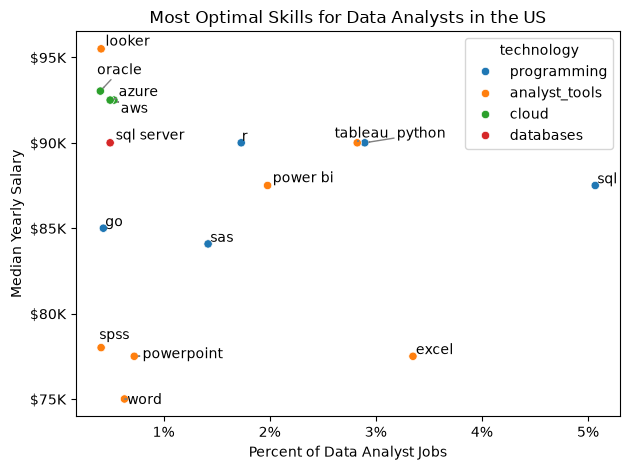

In [40]:
from adjustText import adjust_text

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

# Prepare texts for adjustText
texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(
        plt.text(
            df_DA_skills_high_demand['skill_percent'].iloc[i],
            df_DA_skills_high_demand['median_salary'].iloc[i],
            txt
        )
    )

# Adjust text to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray')
)

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
)
ax.xaxis.set_major_formatter(
    PercentFormatter(decimals=0)
)

# Adjust layout and display plot
plt.tight_layout()
plt.show()

In [41]:
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,714,87500.0,5.068863
excel,472,77500.0,3.350845
python,408,90000.0,2.896493
tableau,398,90000.0,2.825500
power bi,279,87500.0,1.980690
r,244,90000.0,1.732216
sas,200,84078.5,1.419849
powerpoint,102,77500.0,0.724123
word,89,75000.0,0.631833


In [42]:
df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,714,87500.0,5.068863,programming,sql
1,472,77500.0,3.350845,analyst_tools,excel
2,408,90000.0,2.896493,programming,python
3,398,90000.0,2.825500,analyst_tools,tableau
4,279,87500.0,1.980690,analyst_tools,power bi
5,244,90000.0,1.732216,programming,r
6,200,84078.5,1.419849,analyst_tools,sas
7,200,84078.5,1.419849,programming,sas
8,102,77500.0,0.724123,analyst_tools,powerpoint
9,89,75000.0,0.631833,analyst_tools,word
